In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tenseal as ts
import matplotlib.pyplot as plt

os.makedirs(
    "../Outputs/Notebook_10",
    exist_ok=True
)

print(
    "Libraries Loaded Successfully"
)

Libraries Loaded Successfully


# Load Encryption Context

In [2]:
with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

context = ts.context_from(
    context_bytes
)

print(
    "Encryption Context Loaded"
)

Encryption Context Loaded


# Load Encrypted Templates

In [3]:
with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(
    "Encrypted Templates Loaded"
)

print(
    "Total Templates:",
    len(encrypted_embeddings)
)

Encrypted Templates Loaded
Total Templates: 7172


# Load Compressed Features

In [4]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/normalized_features.csv"
)

print(
    compressed_df.shape
)

(7172, 128)


# Load Encrypted Vectors

In [5]:
encrypted_vectors = []

for enc in encrypted_embeddings:

    encrypted_vectors.append(

        ts.ckks_vector_from(
            context,
            enc
        )

    )

print(
    "Encrypted Vectors Loaded"
)

print(
    len(encrypted_vectors)
)

Encrypted Vectors Loaded
7172


# Encrypted Similarity Function

In [6]:
def encrypted_similarity(
    enc_vec1,
    enc_vec2
):

    result = enc_vec1.dot(
        enc_vec2
    )

    return result.decrypt()[0]

# Authentication Demonstration

In [7]:
query_index = 0

stored_index = 1

score = encrypted_similarity(

    encrypted_vectors[query_index],
    encrypted_vectors[stored_index]

)

print(
    "Similarity Score:",
    score
)

Similarity Score: -0.15794756623751405


# Authentication Decision

In [8]:
threshold = 0.16577781326408725

if score > threshold:

    prediction = "GENUINE USER"

else:

    prediction = "IMPOSTOR USER"

print(
    "Threshold:",
    threshold
)

print(
    "Prediction:",
    prediction
)

Threshold: 0.16577781326408725
Prediction: IMPOSTOR USER


# Authentication Result Visualization

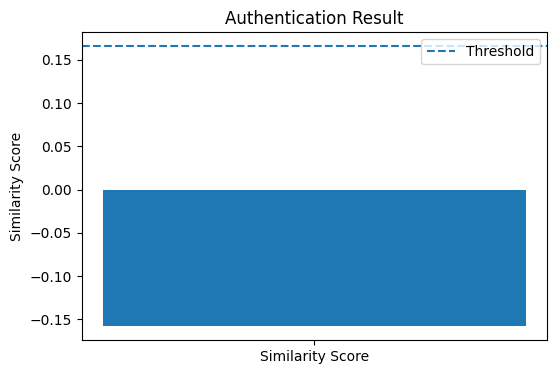

In [9]:
plt.figure(
    figsize=(6,4)
)

plt.bar(

    ["Similarity Score"],
    [score]

)

plt.axhline(

    threshold,

    linestyle="--",

    label="Threshold"

)

plt.title(
    "Authentication Result"
)

plt.ylabel(
    "Similarity Score"
)

plt.legend()

plt.savefig(

    "../Outputs/Notebook_10/authentication_result.png"

)

plt.show()

# Final Authentication Report

In [10]:
final_report = pd.DataFrame({

    "Metric": [

        "Similarity Score",
        "Threshold",
        "Prediction"

    ],

    "Value": [

        score,
        threshold,
        prediction

    ]

})

final_report.to_csv(

    "../Outputs/Notebook_10/final_authentication_report.csv",

    index=False

)

print(
    "Final Authentication Report Saved"
)

final_report

Final Authentication Report Saved


,Metric,Value
0,Similarity Score,-0.157948
1,Threshold,0.165778
2,Prediction,IMPOSTOR USER


# Genuine User Authentication Demonstration

In [11]:
query_index = 0

stored_index = 0

genuine_score = encrypted_similarity(

    encrypted_vectors[query_index],
    encrypted_vectors[stored_index]

)

print(
    "Similarity Score:",
    genuine_score
)

Similarity Score: 1.0000000688717174


In [12]:
threshold = 0.16577781326408725

if genuine_score > threshold:

    genuine_prediction = "GENUINE USER"

else:

    genuine_prediction = "IMPOSTOR USER"

print(
    "Threshold:",
    threshold
)

print(
    "Prediction:",
    genuine_prediction
)

Threshold: 0.16577781326408725
Prediction: GENUINE USER


# Genuine Authentication Result Visualization

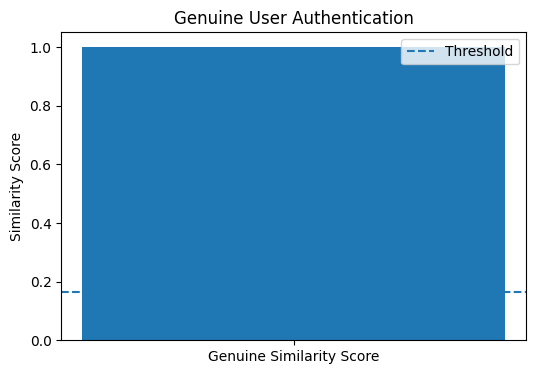

In [13]:
plt.figure(
    figsize=(6,4)
)

plt.bar(

    ["Genuine Similarity Score"],
    [genuine_score]

)

plt.axhline(

    threshold,

    linestyle="--",

    label="Threshold"

)

plt.title(
    "Genuine User Authentication"
)

plt.ylabel(
    "Similarity Score"
)

plt.legend()

plt.savefig(

    "../Outputs/Notebook_10/genuine_authentication_result.png"

)

plt.show()

In [14]:
genuine_report = pd.DataFrame({

    "Metric": [

        "Similarity Score",
        "Threshold",
        "Prediction"

    ],

    "Value": [

        genuine_score,
        threshold,
        genuine_prediction

    ]

})

genuine_report.to_csv(

    "../Outputs/Notebook_10/genuine_authentication_report.csv",

    index=False

)

genuine_report

,Metric,Value
0,Similarity Score,1.0
1,Threshold,0.165778
2,Prediction,GENUINE USER
